# Process Simulation Engine - Demo



## 1. Setup

In [3]:
import sys
from pathlib import Path
import pandas as pd
import pm4py

# Add project root to path
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

from integration.config import SimulationConfig
from integration.setup import setup_simulation
from simulation.engine import DESEngine
from simulation.log_exporter import LogExporter
from resources import ResourceAllocator

print("Setup complete")

Setup complete


## 2. Configuration

In [4]:
# Parameters
EVENT_LOG_PATH = "Dataset/BPI Challenge 2017.xes"
NUM_CASES = 100  # Number of cases to simulate
OUTPUT_DIR = "integration/output"

print(f"Event Log: {EVENT_LOG_PATH}")
print(f"Number of Cases: {NUM_CASES}")

Event Log: Dataset/BPI Challenge 2017.xes
Number of Cases: 100


## 3. Load and Filter Ground Truth

In [5]:
# Load event log
log = pm4py.read_xes(EVENT_LOG_PATH)
df = pm4py.convert_to_dataframe(log)

print(f"Complete event log: {len(df)} events, {df['case:concept:name'].nunique()} cases")

# Select first N cases by arrival time
case_arrivals = df.groupby('case:concept:name')['time:timestamp'].min().sort_values()
selected_cases = case_arrivals.head(NUM_CASES).index.tolist()
ground_truth_df = df[df['case:concept:name'].isin(selected_cases)].copy()

# Filter lifecycle to 'start' and 'complete'
if 'lifecycle:transition' in ground_truth_df.columns:
    before = len(ground_truth_df)
    ground_truth_df = ground_truth_df[
        ground_truth_df['lifecycle:transition'].isin(['start', 'complete'])
    ].copy()
    print(f"Lifecycle Filter: {before} -> {len(ground_truth_df)} events")

print(f"\nGround Truth: {len(ground_truth_df)} events, {ground_truth_df['case:concept:name'].nunique()} cases")
ground_truth_df.head()

Complete event log: 1202267 events, 31509 cases
Lifecycle Filter: 4063 -> 2041 events

Ground Truth: 2041 events, 100 cases


,concept:name,org:resource,case:ApplicationType,Accepted,time:timestamp,MonthlyCost,FirstWithdrawalAmount,OfferID,EventOrigin,case:RequestedAmount,case:concept:name,lifecycle:transition,case:LoanGoal,CreditScore,NumberOfTerms,OfferedAmount,Action,EventID,Selected
0,A_Create Application,User_1,New credit,None,2016-01-01 09:51:15.304000+00:00,NaN,NaN,None,Application,20000.0,Application_652823628,complete,Existing loan takeover,NaN,NaN,NaN,Created,Application_652823628,None
1,A_Submitted,User_1,New credit,None,2016-01-01 09:51:15.352000+00:00,NaN,NaN,None,Application,20000.0,Application_652823628,complete,Existing loan takeover,NaN,NaN,NaN,statechange,ApplState_1582051990,None
5,A_Concept,User_1,New credit,None,2016-01-01 09:52:36.413000+00:00,NaN,NaN,None,Application,20000.0,Application_652823628,complete,Existing loan takeover,NaN,NaN,NaN,statechange,ApplState_642383566,None
6,W_Complete application,User_17,New credit,None,2016-01-02 10:45:22.429000+00:00,NaN,NaN,None,Workflow,20000.0,Application_652823628,start,Existing loan takeover,NaN,NaN,NaN,Obtained,Workitem_1875340971,None
8,A_Accepted,User_52,New credit,None,2016-01-02 11:23:04.299000+00:00,NaN,NaN,None,Application,20000.0,Application_652823628,complete,Existing loan takeover,NaN,NaN,NaN,statechange,ApplState_99568828,None


## 4. Run Simulation

In [6]:
# Create configuration
config = SimulationConfig.all_advanced(
    event_log_path=EVENT_LOG_PATH,
    num_cases=NUM_CASES,
)

# Get start date from event log
start_date = pd.to_datetime(df['time:timestamp']).min().to_pydatetime()

# Prepare predictors
print("Preparing predictors...")
arrivals, next_act_pred, proc_pred, attr_pred = setup_simulation(
    config, df=df, start_date=start_date
)

# Load resource allocator
allocator = ResourceAllocator(log_path=EVENT_LOG_PATH)

# Create and run simulation engine
print("\nRunning simulation...")
engine_start_time = arrivals[0] if arrivals and arrivals[0] < start_date else start_date

engine = DESEngine(
    resource_allocator=allocator,
    arrival_timestamps=arrivals,
    next_activity_predictor=next_act_pred,
    processing_time_predictor=proc_pred,
    case_attribute_predictor=attr_pred,
    start_time=engine_start_time,
)

simulated_events = engine.run(num_cases=len(arrivals))

print(f"\nSimulation complete")
print(f"  Cases started: {engine.stats['cases_started']}")
print(f"  Cases completed: {engine.stats['cases_completed']}")
print(f"  Events generated: {len(simulated_events)}")

Preparing predictors...
Train days: 292 Test days: 74
Train arrivals: 25208
Test arrivals: 6301
simulierte Interarrival-Statistiken (intraday only):
  mean: 1109.5572
  std: 1589.8683
  q05: 129.5334
  q25: 349.0410
  q50: 583.7532
  q75: 1149.4509
  q95: 3706.8083
√CADD = 88.4373
simulierte Interarrival-Statistiken:
  mean: 1140.2740
  std:  1608.4893
  q05:  59.7500
  q25:  267.7500
  q50:  600.0000
  q75:  1373.5000
  q95:  3422.0000


AttributeError: 'SimulationConfig' object has no attribute 'next_activity_class'

In [ ]:
# Convert simulated log to DataFrame
simulated_df = pd.DataFrame(simulated_events)

print(f"Simulated event log: {len(simulated_df)} events, {simulated_df['case:concept:name'].nunique()} cases")
simulated_df.head()

Simulated event log: 1620 events, 100 cases


,case:concept:name,concept:name,org:resource,time:timestamp,lifecycle:transition,case:LoanGoal,case:ApplicationType,case:RequestedAmount,CreditScore,OfferedAmount,FirstWithdrawalAmount,NumberOfTerms,MonthlyCost,Selected,Accepted
0,Application_45852356,A_Create Application,User_1,2016-01-01 03:09:07.383085+00:00,complete,"Other, see explanation",New credit,8000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Application_169421658,A_Create Application,User_1,2016-01-01 06:12:45.273168+00:00,complete,Existing loan takeover,New credit,17000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Application_1638192169,A_Create Application,User_1,2016-01-01 09:36:39.001651+00:00,complete,Unknown,Limit raise,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Application_1478350508,A_Create Application,User_1,2016-01-01 12:28:03.057927+00:00,complete,Car,New credit,12000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Application_1679868038,A_Create Application,User_1,2016-01-01 15:17:46.478866+00:00,complete,Home improvement,Limit raise,46500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Comparison: Key Metrics

In [ ]:
# Calculate statistics
def calculate_key_stats(df, name):
    stats = {}
    stats['Total Events'] = len(df)
    stats['Total Cases'] = df['case:concept:name'].nunique()
    stats['Unique Activities'] = df['concept:name'].nunique()
    
    # Events pro Case
    events_per_case = df.groupby('case:concept:name').size()
    stats['Avg Events/Case'] = round(events_per_case.mean(), 2)
    
    # Case Duration
    df_temp = df.copy()
    df_temp['time:timestamp'] = pd.to_datetime(df_temp['time:timestamp'])
    case_durations = df_temp.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
    case_durations['duration_hours'] = (case_durations['max'] - case_durations['min']).dt.total_seconds() / 3600
    stats['Avg Duration (h)'] = round(case_durations['duration_hours'].mean(), 2)
    
    if 'org:resource' in df.columns:
        stats['Unique Resources'] = df['org:resource'].nunique()
    
    return stats

gt_stats = calculate_key_stats(ground_truth_df, "GT")
sim_stats = calculate_key_stats(simulated_df, "Sim")

comparison = pd.DataFrame({
    'Ground Truth': gt_stats,
    'Simulated': sim_stats
})

comparison['Diff (%)'] = comparison.apply(
    lambda row: round((row['Simulated'] - row['Ground Truth']) / row['Ground Truth'] * 100, 1) 
    if row['Ground Truth'] != 0 else 0, axis=1
)

print("\nComparison Ground Truth vs. Simulation\n")
comparison


Comparison Ground Truth vs. Simulation



,Ground Truth,Simulated,Diff (%)
Total Events,2041.00,1620.00,-20.6
Total Cases,100.00,100.00,0.0
Unique Activities,23.00,25.00,8.7
Avg Events/Case,20.41,16.20,-20.6
Avg Duration (h),594.86,725.18,21.9
Unique Resources,60.00,85.00,41.7


## 6. Activity Distribution

In [ ]:
# Activity Frequencies
gt_activities = ground_truth_df['concept:name'].value_counts()
sim_activities = simulated_df['concept:name'].value_counts()

activity_comp = pd.DataFrame({
    'Ground Truth': gt_activities,
    'Simulated': sim_activities
}).fillna(0)

activity_comp['Diff'] = activity_comp['Simulated'] - activity_comp['Ground Truth']

print("Top 10 Activities:")
activity_comp.head(10)

Top 10 Activities:


,Ground Truth,Simulated,Diff
concept:name,,,
A_Accepted,100.0,100,0.0
A_Cancelled,35.0,78,43.0
A_Complete,100.0,100,0.0
A_Concept,100.0,100,0.0
A_Create Application,100.0,100,0.0
A_Denied,9.0,12,3.0
A_Incomplete,67.0,5,-62.0
A_Pending,56.0,10,-46.0
A_Submitted,82.0,82,0.0


## 7. Process Discovery: DFG Comparison

Ground Truth DFG:


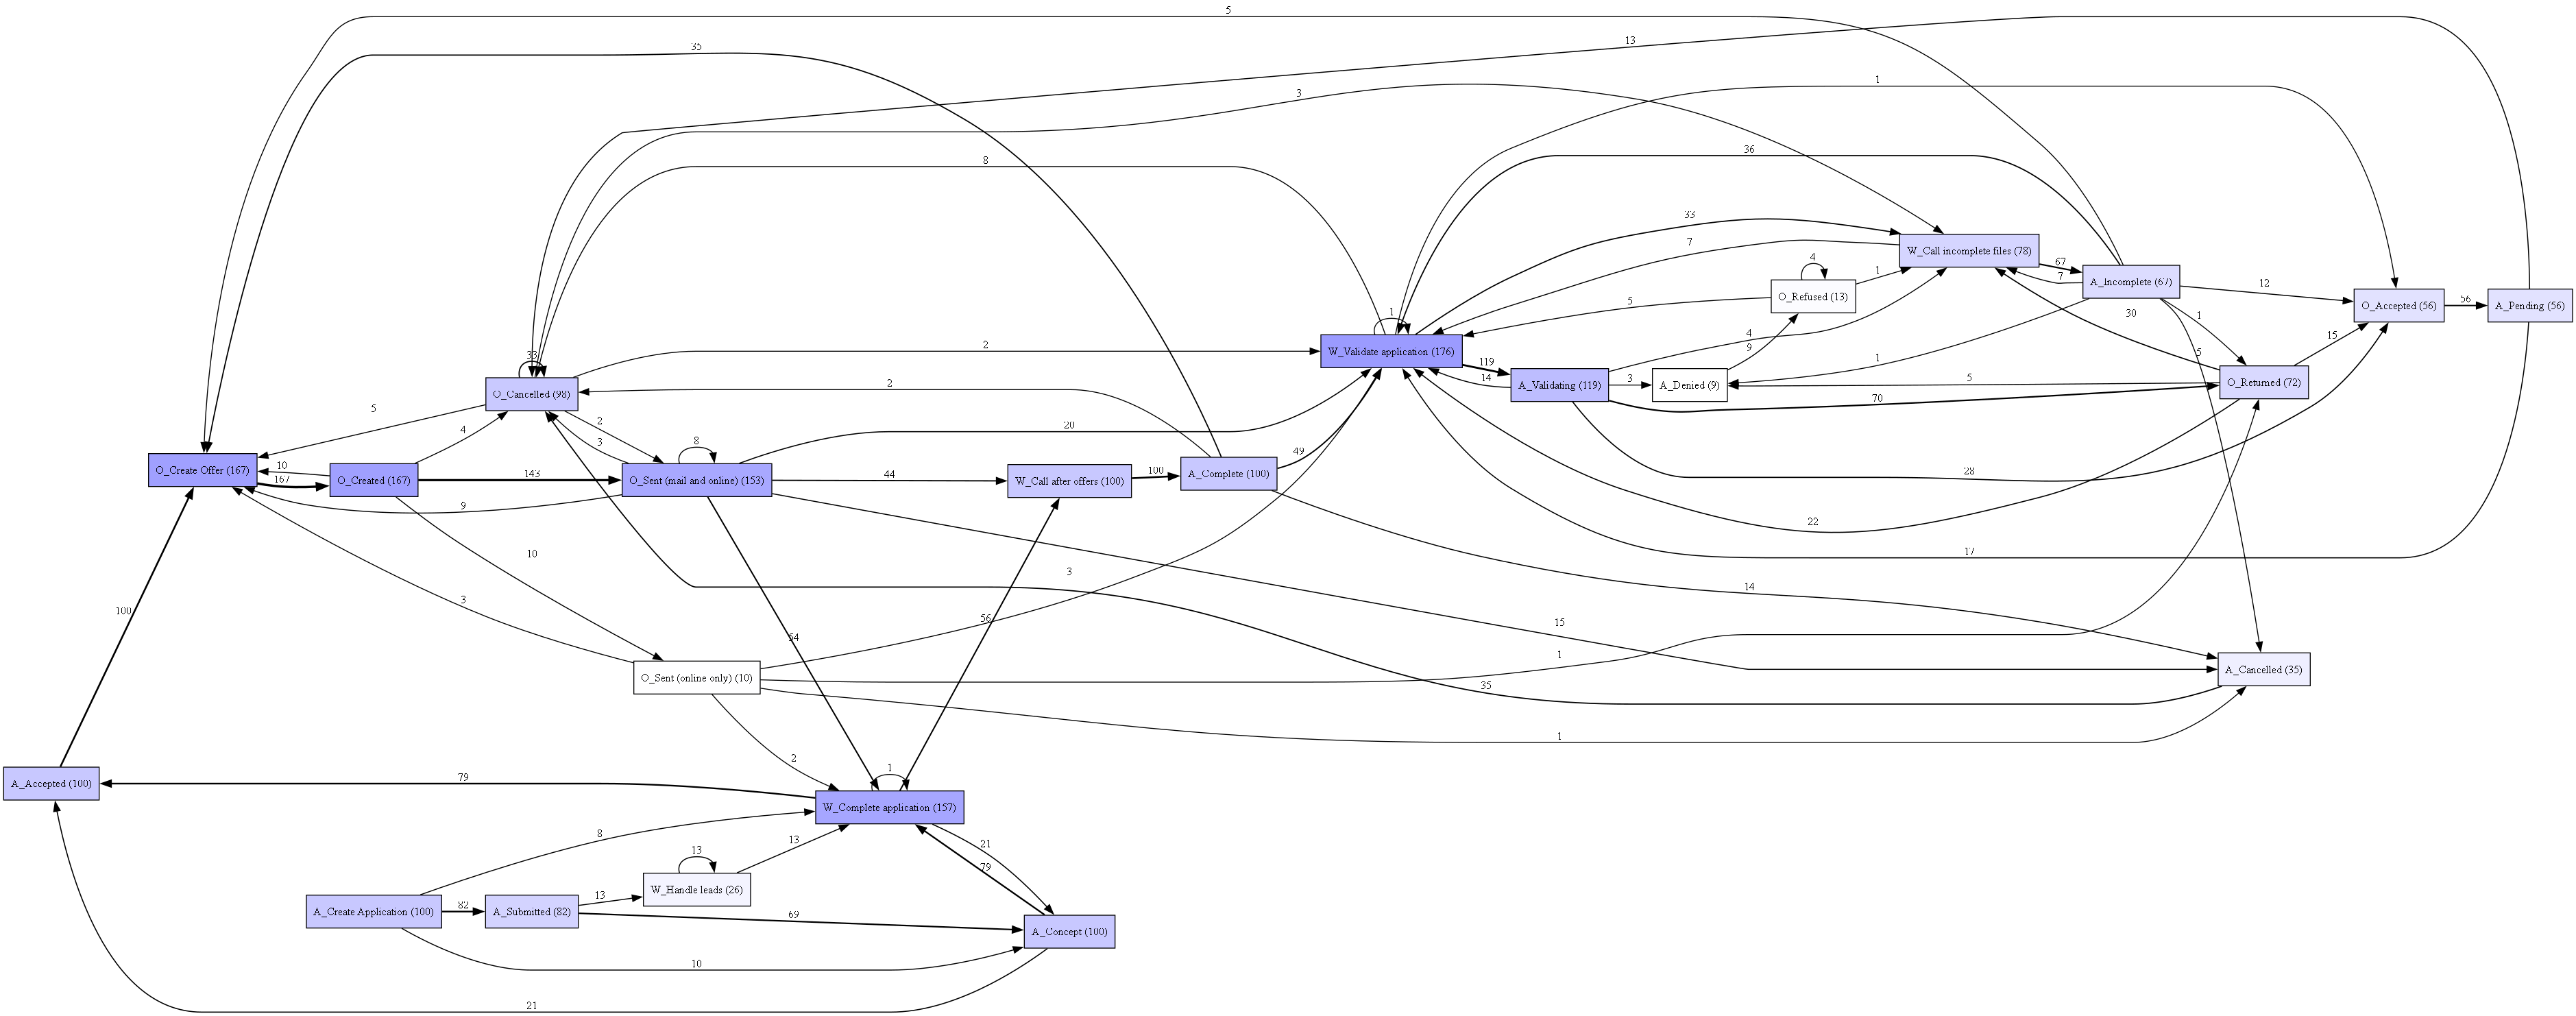

In [ ]:
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_visualizer

# Convert to event logs
gt_log = pm4py.convert_to_event_log(ground_truth_df)
sim_log = pm4py.convert_to_event_log(simulated_df)

# Discover DFGs
gt_dfg = dfg_discovery.apply(gt_log)
sim_dfg = dfg_discovery.apply(sim_log)

# Visualize Ground Truth
print("Ground Truth DFG:")
gt_dfg_viz = dfg_visualizer.apply(gt_dfg, log=gt_log, variant=dfg_visualizer.Variants.FREQUENCY)
dfg_visualizer.view(gt_dfg_viz)

Simulated DFG:


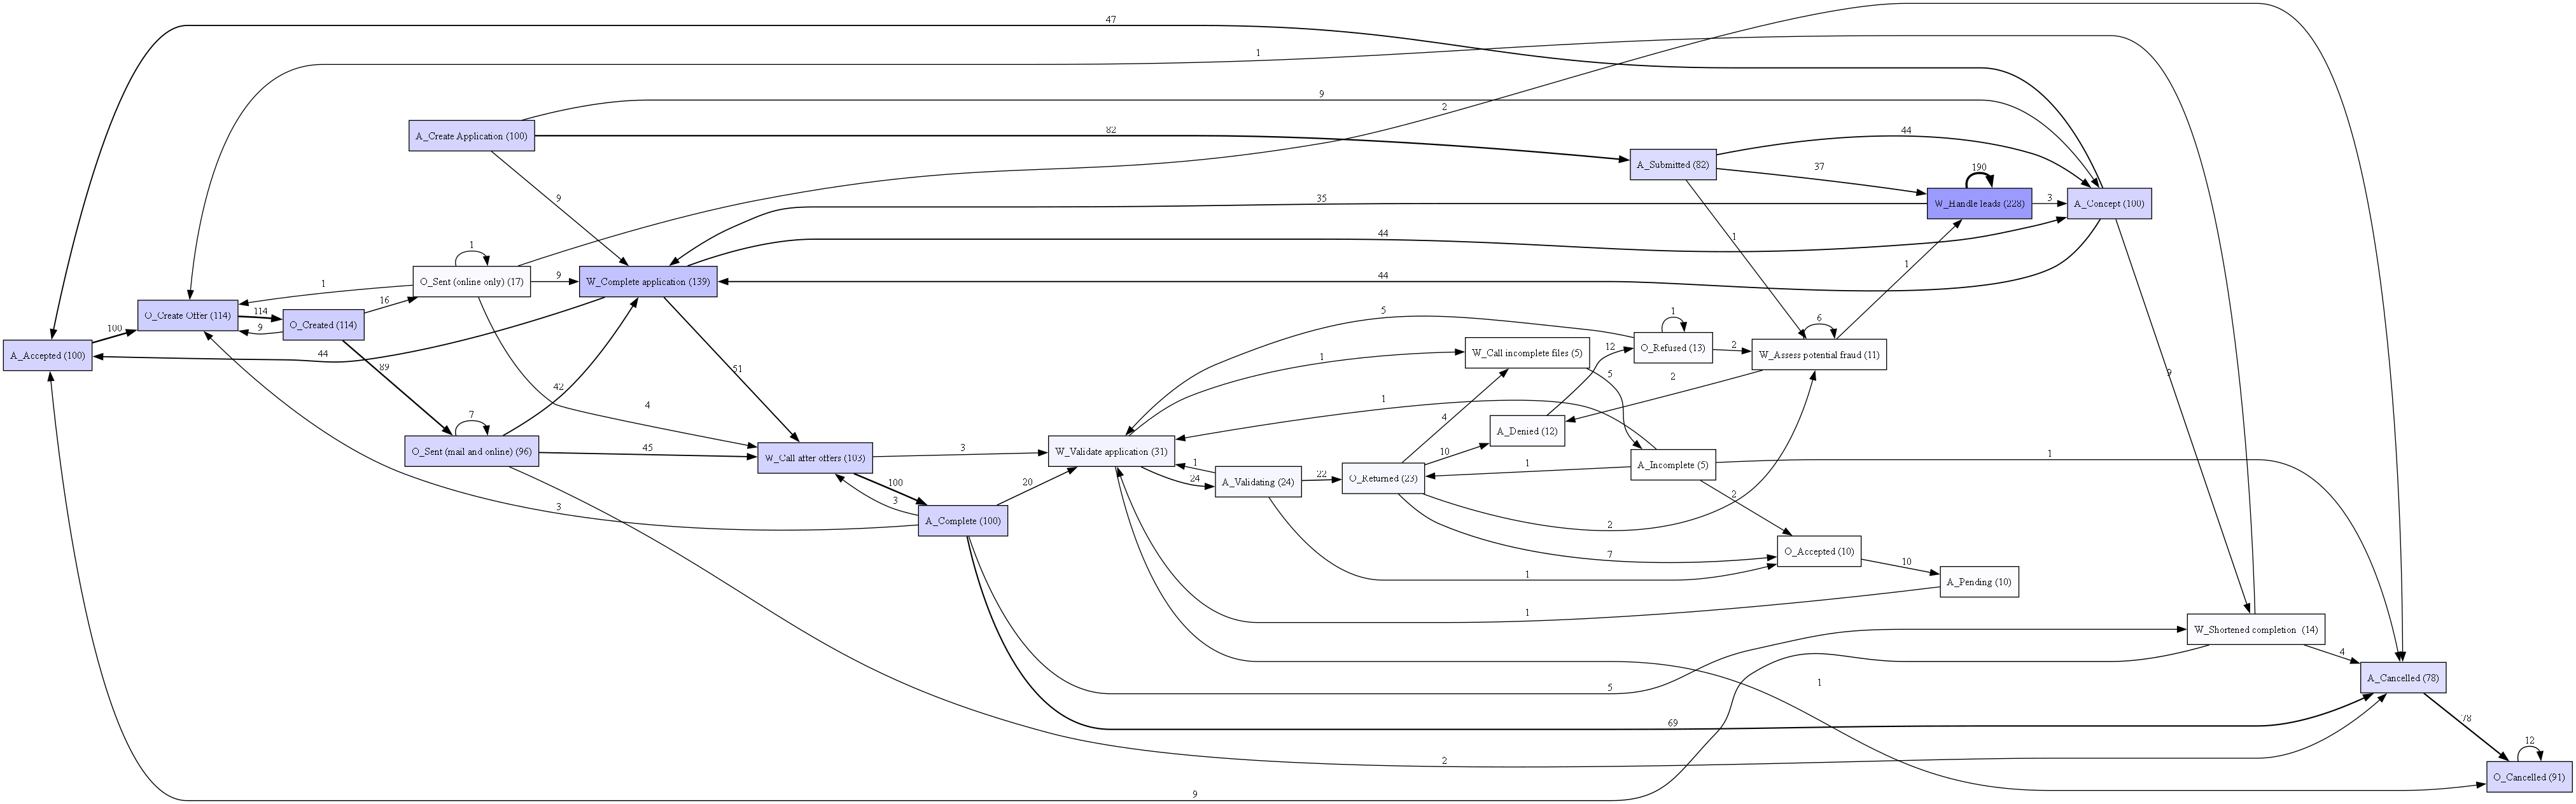

In [ ]:
# Visualize Simulated
print("Simulated DFG:")
sim_dfg_viz = dfg_visualizer.apply(sim_dfg, log=sim_log, variant=dfg_visualizer.Variants.FREQUENCY)
dfg_visualizer.view(sim_dfg_viz)

In [ ]:
# DFG Edge Comparison
gt_edges = set(gt_dfg.keys())
sim_edges = set(sim_dfg.keys())
common_edges = gt_edges & sim_edges

print("\nDFG Edge Overlap:")
print(f"  Ground Truth: {len(gt_edges)} edges")
print(f"  Simulated: {len(sim_edges)} edges")
print(f"  Common: {len(common_edges)} ({len(common_edges)/len(gt_edges)*100:.1f}%)")
print(f"  Only in GT: {len(gt_edges - sim_edges)}")
print(f"  Only in Sim: {len(sim_edges - gt_edges)}")


DFG Edge Overlap:
  Ground Truth: 72 edges
  Simulated: 65 edges
  Common: 49 (68.1%)
  Only in GT: 23
  Only in Sim: 16


## 8. Summary

In [ ]:
print("\n" + "="*60)
print("DEMO SUMMARY")
print("="*60)
print(f"\n{NUM_CASES} cases simulated")
print(f"{len(simulated_df)} events generated")
print(f"{len(common_edges)/len(gt_edges)*100:.1f}% DFG edge overlap")
print(f"Avg {abs(comparison.loc['Avg Events/Case', 'Diff (%)']):.1f}% deviation in Events/Case")
print(f"Avg {abs(comparison.loc['Avg Duration (h)', 'Diff (%)']):.1f}% deviation in Case Duration")
print("\n" + "="*60)
print("Demo complete")
print("="*60)


DEMO SUMMARY

100 cases simulated
1620 events generated
68.1% DFG edge overlap
Avg 20.6% deviation in Events/Case
Avg 21.9% deviation in Case Duration

Demo complete


## 9. Case Throughput Time Analysis (Simulated)

In [ ]:
# Calculate throughput time for simulated cases
sim_df_temp = simulated_df.copy()
sim_df_temp['time:timestamp'] = pd.to_datetime(sim_df_temp['time:timestamp'])

case_times = sim_df_temp.groupby('case:concept:name')['time:timestamp'].agg(['min', 'max'])
case_times['throughput_time_hours'] = (case_times['max'] - case_times['min']).dt.total_seconds() / 3600
case_times['throughput_time_days'] = case_times['throughput_time_hours'] / 24

# Get resources used per case
if 'org:resource' in sim_df_temp.columns:
    case_resources = sim_df_temp.groupby('case:concept:name')['org:resource'].apply(
        lambda x: ', '.join(sorted(x.unique()))
    )
    case_times['resources'] = case_resources
    case_times['num_resources'] = sim_df_temp.groupby('case:concept:name')['org:resource'].nunique()

# Summary statistics
throughput_stats = pd.DataFrame({
    'Throughput Time (hours)': [
        case_times['throughput_time_hours'].mean(),
        case_times['throughput_time_hours'].median(),
        case_times['throughput_time_hours'].std(),
        case_times['throughput_time_hours'].min(),
        case_times['throughput_time_hours'].max()
    ]
}, index=['Mean', 'Median', 'Std Dev', 'Min', 'Max'])

print("\nCase Throughput Time Statistics (Simulated)\n")
print(throughput_stats.round(2))

print(f"\n{'='*60}")
print(f"Average Throughput Time: {case_times['throughput_time_hours'].mean():.2f} hours ({case_times['throughput_time_days'].mean():.2f} days)")
print(f"Median Throughput Time:  {case_times['throughput_time_hours'].median():.2f} hours ({case_times['throughput_time_days'].median():.2f} days)")
print(f"Min Throughput Time:     {case_times['throughput_time_hours'].min():.2f} hours")
print(f"Max Throughput Time:     {case_times['throughput_time_hours'].max():.2f} hours")
print(f"{'='*60}")

# Show individual case throughput times with resources
if 'org:resource' in sim_df_temp.columns:
    case_times_display = case_times[['throughput_time_hours', 'throughput_time_days', 'num_resources', 'resources']].round(2)
    case_times_display.columns = ['Hours', 'Days', '# Resources', 'Resources Used']
else:
    case_times_display = case_times[['throughput_time_hours', 'throughput_time_days']].round(2)
    case_times_display.columns = ['Hours', 'Days']

print("\nIndividual Case Throughput Times:\n")
case_times_display


Case Throughput Time Statistics (Simulated)

         Throughput Time (hours)
Mean                      725.18
Median                    587.65
Std Dev                   448.43
Min                        89.10
Max                      2721.18

Average Throughput Time: 725.18 hours (30.22 days)
Median Throughput Time:  587.65 hours (24.49 days)
Min Throughput Time:     89.10 hours
Max Throughput Time:     2721.18 hours

Individual Case Throughput Times:



,Hours,Days,# Resources,Resources Used
case:concept:name,,,,
Application_1036987904,767.10,31.96,11,"User_1, User_11, User_112, User_118, User_140,..."
Application_1071421767,1647.85,68.66,17,"User_1, User_113, User_125, User_17, User_28, ..."
Application_1108027667,475.19,19.80,11,"User_1, User_18, User_27, User_36, User_4, Use..."
Application_1142460599,532.62,22.19,16,"User_1, User_101, User_24, User_28, User_33, U..."
Application_1155052037,1044.78,43.53,12,"User_1, User_117, User_14, User_144, User_27, ..."
...,...,...,...,...
Application_897598533,1484.64,61.86,9,"User_1, User_10, User_17, User_19, User_5, Use..."
Application_923397331,566.80,23.62,18,"User_1, User_109, User_11, User_14, User_15, U..."
Application_939167320,182.04,7.59,9,"User_1, User_117, User_12, User_14, User_15, U..."


In [ ]:
from IPython.display import HTML

# Create styled HTML output
html = """
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;600;700&display=swap');

.throughput-container {{
    font-family: 'Poppins', sans-serif;
    background: #ffffff;
    padding: 30px;
    border-radius: 10px;
    box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);
    max-width: 1200px;
    margin: 20px auto;
}}

.throughput-title {{
    font-size: 28px;
    font-weight: 700;
    color: #000000;
    margin-bottom: 10px;
    text-align: center;
    border-bottom: 3px solid #000000;
    padding-bottom: 15px;
}}

.stats-grid {{
    display: grid;
    grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
    gap: 20px;
    margin: 30px 0;
}}

.stat-card {{
    background: #f8f8f8;
    border: 2px solid #000000;
    border-radius: 8px;
    padding: 20px;
    text-align: center;
}}

.stat-label {{
    font-size: 14px;
    font-weight: 400;
    color: #666666;
    margin-bottom: 8px;
}}

.stat-value {{
    font-size: 24px;
    font-weight: 700;
    color: #000000;
}}

.stat-subvalue {{
    font-size: 12px;
    font-weight: 300;
    color: #888888;
    margin-top: 4px;
}}

.table-container {{
    overflow-x: auto;
    margin-top: 30px;
}}

.throughput-table {{
    width: 100%;
    border-collapse: collapse;
    font-size: 14px;
}}

.throughput-table th {{
    background: #000000;
    color: #ffffff;
    padding: 12px;
    text-align: left;
    font-weight: 600;
    border: 1px solid #000000;
}}

.throughput-table td {{
    padding: 10px 12px;
    border: 1px solid #e0e0e0;
    color: #333333;
}}

.throughput-table tr:nth-child(even) {{
    background: #f8f8f8;
}}

.throughput-table tr:hover {{
    background: #e8e8e8;
}}

.section-title {{
    font-size: 20px;
    font-weight: 600;
    color: #000000;
    margin: 30px 0 15px 0;
    padding-bottom: 10px;
    border-bottom: 2px solid #cccccc;
}}
</style>

<div class="throughput-container">
    <div class="throughput-title">Case Throughput Time Analysis (Simulated)</div>
    
    <div class="stats-grid">
        <div class="stat-card">
            <div class="stat-label">Mean</div>
            <div class="stat-value">{mean_hours:.2f}h</div>
            <div class="stat-subvalue">{mean_days:.2f} days</div>
        </div>
        <div class="stat-card">
            <div class="stat-label">Median</div>
            <div class="stat-value">{median_hours:.2f}h</div>
            <div class="stat-subvalue">{median_days:.2f} days</div>
        </div>
        <div class="stat-card">
            <div class="stat-label">Std Dev</div>
            <div class="stat-value">{std_hours:.2f}h</div>
            <div class="stat-subvalue">±{std_days:.2f} days</div>
        </div>
        <div class="stat-card">
            <div class="stat-label">Min</div>
            <div class="stat-value">{min_hours:.2f}h</div>
            <div class="stat-subvalue">{min_days:.2f} days</div>
        </div>
        <div class="stat-card">
            <div class="stat-label">Max</div>
            <div class="stat-value">{max_hours:.2f}h</div>
            <div class="stat-subvalue">{max_days:.2f} days</div>
        </div>
    </div>
    
    <div class="section-title">Individual Case Details</div>
    <div class="table-container">
        <table class="throughput-table">
            <thead>
                <tr>
                    <th>Case ID</th>
                    <th>Hours</th>
                    <th>Days</th>
                    <th>#Resources</th>
                    <th>Resources Used</th>
                </tr>
            </thead>
            <tbody>
                {table_rows}
            </tbody>
        </table>
    </div>
</div>
"""

# Generate table rows
table_rows = ""
for case_id, row in case_times.iterrows():
    hours = row['throughput_time_hours']
    days = row['throughput_time_days']
    num_res = row['num_resources'] if 'num_resources' in row else 'N/A'
    resources = row['resources'] if 'resources' in row else 'N/A'
    
    table_rows += f"""
                <tr>
                    <td style="font-weight: 600;">{case_id}</td>
                    <td>{hours:.2f}</td>
                    <td>{days:.2f}</td>
                    <td>{num_res}</td>
                    <td style="font-size: 12px;">{resources}</td>
                </tr>
    """

# Fill in the template
formatted_html = html.format(
    mean_hours=case_times['throughput_time_hours'].mean(),
    mean_days=case_times['throughput_time_days'].mean(),
    median_hours=case_times['throughput_time_hours'].median(),
    median_days=case_times['throughput_time_days'].median(),
    std_hours=case_times['throughput_time_hours'].std(),
    std_days=case_times['throughput_time_days'].std(),
    min_hours=case_times['throughput_time_hours'].min(),
    min_days=case_times['throughput_time_days'].min(),
    max_hours=case_times['throughput_time_hours'].max(),
    max_days=case_times['throughput_time_days'].max(),
    table_rows=table_rows
)

# Display
HTML(formatted_html)

Case ID,Hours,Days,#Resources,Resources Used
Application_1036987904,767.10,31.96,11,"User_1, User_11, User_112, User_118, User_140, User_29, User_33, User_4, User_49, User_52, User_75"
Application_1071421767,1647.85,68.66,17,"User_1, User_113, User_125, User_17, User_28, User_29, User_32, User_34, User_35, User_36, User_37, User_4, User_49, User_5, User_75, User_85, User_86"
Application_1108027667,475.19,19.80,11,"User_1, User_18, User_27, User_36, User_4, User_6, User_68, User_7, User_75, User_90, User_99"
Application_1142460599,532.62,22.19,16,"User_1, User_101, User_24, User_28, User_33, User_35, User_36, User_38, User_41, User_47, User_49, User_50, User_7, User_70, User_75, User_85"
Application_1155052037,1044.78,43.53,12,"User_1, User_117, User_14, User_144, User_27, User_28, User_3, User_33, User_43, User_68, User_74, User_75"
Application_1181966931,147.19,6.13,18,"User_1, User_11, User_140, User_142, User_17, User_18, User_2, User_29, User_35, User_37, User_38, User_41, User_44, User_50, User_6, User_7, User_74, User_75"
Application_1186042604,1460.40,60.85,11,"User_1, User_2, User_26, User_28, User_30, User_35, User_36, User_44, User_52, User_68, User_71"
Application_1239351095,543.59,22.65,14,"User_1, User_11, User_14, User_140, User_15, User_22, User_27, User_28, User_34, User_4, User_41, User_68, User_75, User_8"
Application_123955214,454.28,18.93,10,"User_1, User_10, User_21, User_27, User_36, User_4, User_75, User_8, User_87, User_90"
Application_1249347258,599.28,24.97,10,"User_1, User_117, User_120, User_14, User_144, User_43, User_5, User_52, User_75, User_8"


## 10. Resource Availability Analysis (Simulated)

In [ ]:
# Calculate resource utilization and availability metrics
sim_df_res = simulated_df.copy()

if 'org:resource' in sim_df_res.columns:
    # Get all unique resources
    all_resources = sim_df_res['org:resource'].unique()
    
    # Calculate metrics for each resource
    resource_metrics = []
    
    for resource in all_resources:
        resource_events = sim_df_res[sim_df_res['org:resource'] == resource].copy()
        
        # Total number of events handled
        total_events = len(resource_events)
        
        # Number of unique cases handled
        unique_cases = resource_events['case:concept:name'].nunique()
        
        # Activities performed
        unique_activities = resource_events['concept:name'].nunique()
        activities_list = ', '.join(sorted(resource_events['concept:name'].unique()))
        
        # Convert timestamps
        resource_events['time:timestamp'] = pd.to_datetime(resource_events['time:timestamp'])
        resource_events = resource_events.sort_values('time:timestamp')
        
        # Calculate actual working time (sum of all processing times)
        actual_working_hours = 0
        if 'lifecycle:transition' in resource_events.columns:
            # Group by case and activity to find start-complete pairs
            for (case_id, activity), group in resource_events.groupby(['case:concept:name', 'concept:name']):
                start_events = group[group['lifecycle:transition'] == 'start']
                complete_events = group[group['lifecycle:transition'] == 'complete']
                
                # Match start and complete events
                for start_time in start_events['time:timestamp']:
                    # Find the next complete event after this start
                    matching_complete = complete_events[complete_events['time:timestamp'] > start_time]
                    if not matching_complete.empty:
                        complete_time = matching_complete.iloc[0]['time:timestamp']
                        processing_time = (complete_time - start_time).total_seconds() / 3600
                        actual_working_hours += processing_time
        
        # Calculate timespan (first to last event)
        if len(resource_events) > 1:
            first_event = resource_events['time:timestamp'].min()
            last_event = resource_events['time:timestamp'].max()
            timespan_hours = (last_event - first_event).total_seconds() / 3600
        else:
            timespan_hours = 0
        
        # Calculate utilization
        utilization = (actual_working_hours / timespan_hours * 100) if timespan_hours > 0 else 0
        
        # Average events per case
        avg_events_per_case = total_events / unique_cases if unique_cases > 0 else 0
        
        resource_metrics.append({
            'Resource': resource,
            'Total Events': total_events,
            'Unique Cases': unique_cases,
            'Unique Activities': unique_activities,
            'Activities List': activities_list,
            'Actual Working Time (hours)': round(actual_working_hours, 2),
            'Timespan (hours)': round(timespan_hours, 2),
            'Utilization (%)': round(utilization, 1),
            'Avg Events/Case': round(avg_events_per_case, 2)
        })
    
    # Create DataFrame
    resource_stats_df = pd.DataFrame(resource_metrics)
    resource_stats_df = resource_stats_df.sort_values('Total Events', ascending=False)
    
    # Overall statistics
    print("Resource Availability & Utilization Statistics\n")
    print(f"Total Resources: {len(all_resources)}")
    print(f"Total Events: {len(sim_df_res)}")
    print(f"Avg Events per Resource: {resource_stats_df['Total Events'].mean():.2f}")
    print(f"Avg Cases per Resource: {resource_stats_df['Unique Cases'].mean():.2f}")
    print(f"Avg Actual Working Time per Resource: {resource_stats_df['Actual Working Time (hours)'].mean():.2f} hours")
    print(f"Avg Timespan per Resource: {resource_stats_df['Timespan (hours)'].mean():.2f} hours")
    print(f"Avg Utilization: {resource_stats_df['Utilization (%)'].mean():.1f}%")
    print(f"\n{'='*80}")
    
    # Display detailed table
    display_df = resource_stats_df[['Resource', 'Total Events', 'Unique Cases', 
                                      'Unique Activities', 'Actual Working Time (hours)',
                                      'Timespan (hours)', 'Utilization (%)', 
                                      'Avg Events/Case']].copy()
    print("\nDetailed Resource Metrics:\n")
    display_df
else:
    print("No resource information available in simulated log")
    resource_stats_df = None

Resource Availability & Utilization Statistics

Total Resources: 85
Total Events: 1620
Avg Events per Resource: 19.06
Avg Cases per Resource: 14.73
Avg Actual Working Time per Resource: 0.00 hours
Avg Timespan per Resource: 1534.55 hours
Avg Utilization: 0.0%


Detailed Resource Metrics:



In [ ]:
# Calculate resource metrics for Ground Truth for comparison
def calculate_resource_metrics(df, name):
    """Calculate resource utilization metrics for a given dataframe"""
    if 'org:resource' not in df.columns:
        return None
    
    all_resources = df['org:resource'].unique()
    resource_metrics = []
    
    for resource in all_resources:
        resource_events = df[df['org:resource'] == resource].copy()
        total_events = len(resource_events)
        unique_cases = resource_events['case:concept:name'].nunique()
        unique_activities = resource_events['concept:name'].nunique()
        
        # Convert timestamp
        resource_events['time:timestamp'] = pd.to_datetime(resource_events['time:timestamp'])
        resource_events = resource_events.sort_values('time:timestamp')
        
        # Calculate actual working time (sum of all processing times)
        actual_working_hours = 0
        if 'lifecycle:transition' in resource_events.columns:
            # Group by case and activity to find start-complete pairs
            for (case_id, activity), group in resource_events.groupby(['case:concept:name', 'concept:name']):
                start_events = group[group['lifecycle:transition'] == 'start']
                complete_events = group[group['lifecycle:transition'] == 'complete']
                
                # Match start and complete events
                for start_time in start_events['time:timestamp']:
                    # Find the next complete event after this start
                    matching_complete = complete_events[complete_events['time:timestamp'] > start_time]
                    if not matching_complete.empty:
                        complete_time = matching_complete.iloc[0]['time:timestamp']
                        processing_time = (complete_time - start_time).total_seconds() / 3600
                        actual_working_hours += processing_time
        
        # Calculate timespan (first to last event)
        if len(resource_events) > 1:
            timespan_hours = (resource_events['time:timestamp'].max() - resource_events['time:timestamp'].min()).total_seconds() / 3600
        else:
            timespan_hours = 0
        
        avg_events_per_case = total_events / unique_cases if unique_cases > 0 else 0
        
        resource_metrics.append({
            'Resource': resource,
            'Total Events': total_events,
            'Unique Cases': unique_cases,
            'Unique Activities': unique_activities,
            'Actual Working Time (hours)': round(actual_working_hours, 2),
            'Timespan (hours)': round(timespan_hours, 2),
            'Utilization (%)': round((actual_working_hours / timespan_hours * 100) if timespan_hours > 0 else 0, 1),
            'Avg Events/Case': round(avg_events_per_case, 2)
        })
    
    df_result = pd.DataFrame(resource_metrics)
    return df_result

# Calculate for both Ground Truth and Simulated
gt_resource_stats = calculate_resource_metrics(ground_truth_df, "Ground Truth")
sim_resource_stats = calculate_resource_metrics(simulated_df, "Simulated")

if gt_resource_stats is not None and sim_resource_stats is not None:
    # Overall comparison
    comparison_resources = pd.DataFrame({
        'Ground Truth': [
            len(gt_resource_stats),
            gt_resource_stats['Total Events'].sum(),
            gt_resource_stats['Total Events'].mean(),
            gt_resource_stats['Unique Cases'].mean(),
            gt_resource_stats['Actual Working Time (hours)'].mean(),
            gt_resource_stats['Timespan (hours)'].mean(),
            gt_resource_stats['Utilization (%)'].mean()
        ],
        'Simulated': [
            len(sim_resource_stats),
            sim_resource_stats['Total Events'].sum(),
            sim_resource_stats['Total Events'].mean(),
            sim_resource_stats['Unique Cases'].mean(),
            sim_resource_stats['Actual Working Time (hours)'].mean(),
            sim_resource_stats['Timespan (hours)'].mean(),
            sim_resource_stats['Utilization (%)'].mean()
        ]
    }, index=['Total Resources', 'Total Events', 'Avg Events/Resource', 'Avg Cases/Resource', 
              'Avg Working Time (h)', 'Avg Timespan (h)', 'Avg Utilization (%)'])
    
    comparison_resources['Diff (%)'] = comparison_resources.apply(
        lambda row: round((row['Simulated'] - row['Ground Truth']) / row['Ground Truth'] * 100, 1) 
        if row['Ground Truth'] != 0 else 0, axis=1
    )
    
    print("\nResource Utilization Comparison: Ground Truth vs. Simulated\n")
    print(comparison_resources.round(2))
    print("\n" + "="*80)
    print("NOTE: 'Actual Working Time' = Sum of all processing times (start to complete)")
    print("      'Timespan' = Time between first and last event")
    print("      'Utilization' = Working Time / Timespan * 100%")
    print("="*80)
else:
    print("Cannot compare: Resource information missing")


Resource Utilization Comparison: Ground Truth vs. Simulated

                      Ground Truth  Simulated  Diff (%)
Total Resources              60.00      85.00      41.7
Total Events               2041.00    1620.00     -20.6
Avg Events/Resource          34.02      19.06     -44.0
Avg Cases/Resource            8.82      14.73      67.1
Avg Working Time (h)          0.11       0.00    -100.0
Avg Timespan (h)            391.53    1534.55     291.9
Avg Utilization (%)           0.46       0.00    -100.0

NOTE: 'Actual Working Time' = Sum of all processing times (start to complete)
      'Timespan' = Time between first and last event
      'Utilization' = Working Time / Timespan * 100%


In [ ]:
# Create styled HTML output for Resource Availability
if resource_stats_df is not None:
    from IPython.display import HTML
    
    html_resource = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;600;700&display=swap');
    
    .resource-container {{
        font-family: 'Poppins', sans-serif;
        background: #ffffff;
        padding: 30px;
        border-radius: 10px;
        box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);
        max-width: 1400px;
        margin: 20px auto;
    }}
    
    .resource-title {{
        font-size: 28px;
        font-weight: 700;
        color: #000000;
        margin-bottom: 10px;
        text-align: center;
        border-bottom: 3px solid #000000;
        padding-bottom: 15px;
    }}
    
    .resource-stats-grid {{
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(180px, 1fr));
        gap: 20px;
        margin: 30px 0;
    }}
    
    .resource-stat-card {{
        background: #f0f8ff;
        border: 2px solid #4682b4;
        border-radius: 8px;
        padding: 20px;
        text-align: center;
    }}
    
    .resource-stat-label {{
        font-size: 14px;
        font-weight: 400;
        color: #333333;
        margin-bottom: 8px;
    }}
    
    .resource-stat-value {{
        font-size: 24px;
        font-weight: 700;
        color: #4682b4;
    }}
    
    .resource-table-container {{
        overflow-x: auto;
        margin-top: 30px;
    }}
    
    .resource-table {{
        width: 100%;
        border-collapse: collapse;
        font-size: 14px;
    }}
    
    .resource-table th {{
        background: #4682b4;
        color: #ffffff;
        padding: 12px;
        text-align: left;
        font-weight: 600;
        border: 1px solid #4682b4;
    }}
    
    .resource-table td {{
        padding: 10px 12px;
        border: 1px solid #e0e0e0;
        color: #333333;
    }}
    
    .resource-table tr:nth-child(even) {{
        background: #f8f8f8;
    }}
    
    .resource-table tr:hover {{
        background: #e8f4f8;
    }}
    
    .resource-name {{
        font-weight: 600;
        color: #4682b4;
    }}
    
    .section-title {{
        font-size: 20px;
        font-weight: 600;
        color: #000000;
        margin: 30px 0 15px 0;
        padding-bottom: 10px;
        border-bottom: 2px solid #cccccc;
    }}
    
    .activity-badge {{
        background: #e8f4f8;
        padding: 2px 8px;
        border-radius: 4px;
        font-size: 12px;
        color: #4682b4;
        margin-right: 5px;
        display: inline-block;
        margin-bottom: 3px;
    }}
    </style>
    
    <div class="resource-container">
        <div class="resource-title">Resource Availability & Utilization Analysis (Simulated)</div>
        
        <div class="resource-stats-grid">
            <div class="resource-stat-card">
                <div class="resource-stat-label">Total Resources</div>
                <div class="resource-stat-value">{total_resources}</div>
            </div>
            <div class="resource-stat-card">
                <div class="resource-stat-label">Avg Events/Resource</div>
                <div class="resource-stat-value">{avg_events:.1f}</div>
            </div>
            <div class="resource-stat-card">
                <div class="resource-stat-label">Avg Cases/Resource</div>
                <div class="resource-stat-value">{avg_cases:.1f}</div>
            </div>
            <div class="resource-stat-card">
                <div class="resource-stat-label">Avg Active Time</div>
                <div class="resource-stat-value">{avg_active_time:.1f}h</div>
            </div>
            <div class="resource-stat-card">
                <div class="resource-stat-label">Most Active</div>
                <div class="resource-stat-value" style="font-size: 16px;">{most_active}</div>
            </div>
        </div>
        
        <div class="section-title">Individual Resource Details</div>
        <div class="resource-table-container">
            <table class="resource-table">
                <thead>
                    <tr>
                        <th>Resource</th>
                        <th>Total Events</th>
                        <th>Unique Cases</th>
                        <th>Unique Activities</th>
                        <th>Active Time (h)</th>
                        <th>Avg Events/Case</th>
                        <th>Activities Performed</th>
                    </tr>
                </thead>
                <tbody>
                    {table_rows}
                </tbody>
            </table>
        </div>
    </div>
    """
    
    # Generate table rows
    table_rows_res = ""
    for _, row in resource_stats_df.iterrows():
        # Format activities as badges
        activities = row['Activities List'].split(', ')
        activities_html = ''.join([f'<span class="activity-badge">{act}</span>' for act in activities[:5]])
        if len(activities) > 5:
            activities_html += f'<span class="activity-badge">+{len(activities)-5} more</span>'
        
        table_rows_res += f"""
                    <tr>
                        <td class="resource-name">{row['Resource']}</td>
                        <td>{row['Total Events']}</td>
                        <td>{row['Unique Cases']}</td>
                        <td>{row['Unique Activities']}</td>
                        <td>{row['Active Time (hours)']:.2f}</td>
                        <td>{row['Avg Events/Case']:.2f}</td>
                        <td>{activities_html}</td>
                    </tr>
        """
    
    # Fill in the template
    formatted_html_resource = html_resource.format(
        total_resources=len(resource_stats_df),
        avg_events=resource_stats_df['Total Events'].mean(),
        avg_cases=resource_stats_df['Unique Cases'].mean(),
        avg_active_time=resource_stats_df['Active Time (hours)'].mean(),
        most_active=resource_stats_df.iloc[0]['Resource'],
        table_rows=table_rows_res
    )
    
    # Display
    HTML(formatted_html_resource)
else:
    print("No resource data available for visualization")

Resource,Total Events,Unique Cases,Unique Activities,Active Time (h),Avg Events/Case,Activities Performed
User_1,275,99,11,0.00,2.78,A_CancelledA_ConceptA_Create ApplicationA_SubmittedO_Cancelled+6 more
User_75,87,60,19,0.00,1.45,A_AcceptedA_CancelledA_CompleteA_ConceptA_Create Application+14 more
User_29,48,38,17,0.00,1.26,A_AcceptedA_CancelledA_CompleteA_ConceptA_Create Application+12 more
User_68,46,40,12,0.00,1.15,A_AcceptedA_CancelledA_CompleteA_ConceptA_Pending+7 more
User_27,37,30,14,0.00,1.23,A_CancelledA_CompleteA_ConceptA_PendingA_Validating+9 more
User_30,36,30,17,0.00,1.20,A_AcceptedA_CancelledA_CompleteA_ConceptA_Create Application+12 more
User_35,31,25,13,0.00,1.24,A_AcceptedA_CancelledA_ConceptA_Create ApplicationA_Validating+8 more
User_4,31,28,13,0.00,1.11,A_CompleteA_ConceptA_Create ApplicationA_ValidatingO_Accepted+8 more
User_43,30,27,15,0.00,1.11,A_AcceptedA_CancelledA_CompleteA_Create ApplicationO_Accepted+10 more
User_28,30,30,15,0.00,1.00,A_AcceptedA_CancelledA_CompleteA_Create ApplicationA_Denied+10 more


In [ ]:
# Styled comparison visualization (Black & White Design)
if gt_resource_stats is not None and sim_resource_stats is not None:
    from IPython.display import HTML, display
    
    html_comparison = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;600;700&display=swap');
    
    .comparison-container {{
        font-family: 'Poppins', sans-serif;
        background: #ffffff;
        padding: 30px;
        border-radius: 10px;
        box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);
        max-width: 1200px;
        margin: 20px auto;
    }}
    
    .comparison-title {{
        font-size: 28px;
        font-weight: 700;
        color: #000000;
        margin-bottom: 10px;
        text-align: center;
        border-bottom: 3px solid #000000;
        padding-bottom: 15px;
    }}
    
    .comparison-grid {{
        display: grid;
        grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));
        gap: 20px;
        margin: 30px 0;
    }}
    
    .comparison-card {{
        background: #f8f8f8;
        border: 2px solid #000000;
        border-radius: 8px;
        padding: 20px;
        text-align: center;
    }}
    
    .comparison-label {{
        font-size: 14px;
        font-weight: 400;
        color: #666666;
        margin-bottom: 12px;
    }}
    
    .comparison-values {{
        display: flex;
        justify-content: space-around;
        align-items: center;
        margin-top: 10px;
    }}
    
    .value-item {{
        text-align: center;
    }}
    
    .value-label {{
        font-size: 11px;
        font-weight: 400;
        color: #888888;
        margin-bottom: 5px;
    }}
    
    .value-number {{
        font-size: 20px;
        font-weight: 700;
        color: #000000;
    }}
    
    .diff-badge {{
        display: inline-block;
        padding: 4px 12px;
        border-radius: 12px;
        font-size: 12px;
        font-weight: 600;
        margin-top: 8px;
    }}
    
    .diff-positive {{
        background: #e8e8e8;
        color: #000000;
        border: 1px solid #666666;
    }}
    
    .diff-negative {{
        background: #f0f0f0;
        color: #333333;
        border: 1px solid #999999;
    }}
    
    .diff-neutral {{
        background: #ffffff;
        color: #666666;
        border: 1px solid #cccccc;
    }}
    </style>
    
    <div class="comparison-container">
        <div class="comparison-title">Resource Metrics: Ground Truth vs. Simulated</div>
        
        <div class="comparison-grid">
            <div class="comparison-card">
                <div class="comparison-label">Total Resources</div>
                <div class="comparison-values">
                    <div class="value-item">
                        <div class="value-label">GT</div>
                        <div class="value-number">{gt_total_resources}</div>
                    </div>
                    <div class="value-item">
                        <div class="value-label">Sim</div>
                        <div class="value-number">{sim_total_resources}</div>
                    </div>
                </div>
                <div class="diff-badge {diff_class_resources}">{diff_resources:+.1f}%</div>
            </div>
            
            <div class="comparison-card">
                <div class="comparison-label">Avg Events/Resource</div>
                <div class="comparison-values">
                    <div class="value-item">
                        <div class="value-label">GT</div>
                        <div class="value-number">{gt_avg_events:.1f}</div>
                    </div>
                    <div class="value-item">
                        <div class="value-label">Sim</div>
                        <div class="value-number">{sim_avg_events:.1f}</div>
                    </div>
                </div>
                <div class="diff-badge {diff_class_events}">{diff_events:+.1f}%</div>
            </div>
            
            <div class="comparison-card">
                <div class="comparison-label">Avg Cases/Resource</div>
                <div class="comparison-values">
                    <div class="value-item">
                        <div class="value-label">GT</div>
                        <div class="value-number">{gt_avg_cases:.1f}</div>
                    </div>
                    <div class="value-item">
                        <div class="value-label">Sim</div>
                        <div class="value-number">{sim_avg_cases:.1f}</div>
                    </div>
                </div>
                <div class="diff-badge {diff_class_cases}">{diff_cases:+.1f}%</div>
            </div>
            
            <div class="comparison-card">
                <div class="comparison-label">Avg Active Time</div>
                <div class="comparison-values">
                    <div class="value-item">
                        <div class="value-label">GT</div>
                        <div class="value-number">{gt_avg_time:.1f}h</div>
                    </div>
                    <div class="value-item">
                        <div class="value-label">Sim</div>
                        <div class="value-number">{sim_avg_time:.1f}h</div>
                    </div>
                </div>
                <div class="diff-badge {diff_class_time}">{diff_time:+.1f}%</div>
            </div>
        </div>
    </div>
    """
    
    # Calculate differences
    gt_total_res = len(gt_resource_stats)
    sim_total_res = len(sim_resource_stats)
    diff_res = ((sim_total_res - gt_total_res) / gt_total_res * 100) if gt_total_res > 0 else 0
    
    gt_avg_ev = gt_resource_stats['Total Events'].mean()
    sim_avg_ev = sim_resource_stats['Total Events'].mean()
    diff_ev = ((sim_avg_ev - gt_avg_ev) / gt_avg_ev * 100) if gt_avg_ev > 0 else 0
    
    gt_avg_cs = gt_resource_stats['Unique Cases'].mean()
    sim_avg_cs = sim_resource_stats['Unique Cases'].mean()
    diff_cs = ((sim_avg_cs - gt_avg_cs) / gt_avg_cs * 100) if gt_avg_cs > 0 else 0
    
    gt_avg_tm = gt_resource_stats['Active Time (hours)'].mean()
    sim_avg_tm = sim_resource_stats['Active Time (hours)'].mean()
    diff_tm = ((sim_avg_tm - gt_avg_tm) / gt_avg_tm * 100) if gt_avg_tm > 0 else 0
    
    def get_diff_class(diff_val):
        if abs(diff_val) < 5:
            return "diff-neutral"
        elif diff_val > 0:
            return "diff-positive"
        else:
            return "diff-negative"
    
    # Fill in the template
    formatted_comparison_html = html_comparison.format(
        gt_total_resources=gt_total_res,
        sim_total_resources=sim_total_res,
        diff_resources=diff_res,
        diff_class_resources=get_diff_class(diff_res),
        
        gt_avg_events=gt_avg_ev,
        sim_avg_events=sim_avg_ev,
        diff_events=diff_ev,
        diff_class_events=get_diff_class(diff_ev),
        
        gt_avg_cases=gt_avg_cs,
        sim_avg_cases=sim_avg_cs,
        diff_cases=diff_cs,
        diff_class_cases=get_diff_class(diff_cs),
        
        gt_avg_time=gt_avg_tm,
        sim_avg_time=sim_avg_tm,
        diff_time=diff_tm,
        diff_class_time=get_diff_class(diff_tm)
    )
    
    # Display
    display(HTML(formatted_comparison_html))

In [ ]:
# Top 10 Most Active Resources Comparison (Black & White Design)
if gt_resource_stats is not None and sim_resource_stats is not None:
    from IPython.display import HTML, display
    
    # Get top 10 from both
    gt_top10 = gt_resource_stats.nlargest(10, 'Total Events')[['Resource', 'Total Events', 'Unique Cases', 'Active Time (hours)']]
    sim_top10 = sim_resource_stats.nlargest(10, 'Total Events')[['Resource', 'Total Events', 'Unique Cases', 'Active Time (hours)']]
    
    html_top10 = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;600;700&display=swap');
    
    .top10-container {{
        font-family: 'Poppins', sans-serif;
        background: #ffffff;
        padding: 30px;
        border-radius: 10px;
        box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);
        max-width: 1400px;
        margin: 20px auto;
    }}
    
    .top10-title {{
        font-size: 28px;
        font-weight: 700;
        color: #000000;
        margin-bottom: 10px;
        text-align: center;
        border-bottom: 3px solid #000000;
        padding-bottom: 15px;
    }}
    
    .top10-grid {{
        display: grid;
        grid-template-columns: 1fr 1fr;
        gap: 30px;
        margin-top: 30px;
    }}
    
    .top10-section {{
        background: #f8f8f8;
        border: 2px solid #000000;
        border-radius: 8px;
        padding: 20px;
    }}
    
    .section-header {{
        font-size: 20px;
        font-weight: 600;
        color: #000000;
        margin-bottom: 15px;
        text-align: center;
        padding-bottom: 10px;
        border-bottom: 2px solid #cccccc;
    }}
    
    .top10-table {{
        width: 100%;
        border-collapse: collapse;
        font-size: 13px;
    }}
    
    .top10-table th {{
        background: #000000;
        color: #ffffff;
        padding: 10px 8px;
        text-align: left;
        font-weight: 600;
        font-size: 12px;
    }}
    
    .top10-table td {{
        padding: 8px;
        border: 1px solid #e0e0e0;
        color: #333333;
    }}
    
    .top10-table tr:nth-child(even) {{
        background: #ffffff;
    }}
    
    .top10-table tr:hover {{
        background: #e8e8e8;
    }}
    
    .rank-cell {{
        font-weight: 700;
        color: #000000;
        text-align: center;
        width: 40px;
    }}
    
    .resource-cell {{
        font-weight: 600;
        color: #000000;
    }}
    
    .medal {{
        display: inline-block;
        width: 20px;
        height: 20px;
        border-radius: 50%;
        text-align: center;
        line-height: 20px;
        font-size: 11px;
        font-weight: 700;
        margin-right: 5px;
    }}
    
    .medal-1 {{ background: #333333; color: #ffffff; }}
    .medal-2 {{ background: #666666; color: #ffffff; }}
    .medal-3 {{ background: #999999; color: #ffffff; }}
    
    @media (max-width: 1000px) {{
        .top10-grid {{
            grid-template-columns: 1fr;
        }}
    }}
    </style>
    
    <div class="top10-container">
        <div class="top10-title">Top 10 Most Active Resources Comparison</div>
        
        <div class="top10-grid">
            <div class="top10-section">
                <div class="section-header">Ground Truth</div>
                <table class="top10-table">
                    <thead>
                        <tr>
                            <th>#</th>
                            <th>Resource</th>
                            <th>Events</th>
                            <th>Cases</th>
                           
                        </tr>
                    </thead>
                    <tbody>
                        {gt_rows}
                    </tbody>
                </table>
            </div>
            
            <div class="top10-section">
                <div class="section-header">Simulated</div>
                <table class="top10-table">
                    <thead>
                        <tr>
                            <th>#</th>
                            <th>Resource</th>
                            <th>Events</th>
                            <th>Cases</th>
                     
                        </tr>
                    </thead>
                    <tbody>
                        {sim_rows}
                    </tbody>
                </table>
            </div>
        </div>
    </div>
    """
    
    # Generate Ground Truth rows
    gt_rows = ""
    for idx, (_, row) in enumerate(gt_top10.iterrows(), 1):
        medal = ""
        if idx == 1:
            medal = '<span class="medal medal-1">1</span>'
        elif idx == 2:
            medal = '<span class="medal medal-2">2</span>'
        elif idx == 3:
            medal = '<span class="medal medal-3">3</span>'
        
        gt_rows += f"""
                        <tr>
                            <td class="rank-cell">{medal if medal else idx}</td>
                            <td class="resource-cell">{row['Resource']}</td>
                            <td>{int(row['Total Events'])}</td>
                            <td>{int(row['Unique Cases'])}</td>
                            <td>{row['Active Time (hours)']:.1f}</td>
                        </tr>
        """
    
    # Generate Simulated rows
    sim_rows = ""
    for idx, (_, row) in enumerate(sim_top10.iterrows(), 1):
        medal = ""
        if idx == 1:
            medal = '<span class="medal medal-1">1</span>'
        elif idx == 2:
            medal = '<span class="medal medal-2">2</span>'
        elif idx == 3:
            medal = '<span class="medal medal-3">3</span>'
        
        sim_rows += f"""
                        <tr>
                            <td class="rank-cell">{medal if medal else idx}</td>
                            <td class="resource-cell">{row['Resource']}</td>
                            <td>{int(row['Total Events'])}</td>
                            <td>{int(row['Unique Cases'])}</td>
                            <td>{row['Active Time (hours)']:.1f}</td>
                        </tr>
        """
    
    # Fill in the template
    formatted_top10_html = html_top10.format(
        gt_rows=gt_rows,
        sim_rows=sim_rows
    )
    
    # Display
    display(HTML(formatted_top10_html))
    
    # Also print summary statistics
    print("\nTop 10 Resources Summary:")
    print("="*60)
    
    # Check overlap
    gt_top10_names = set(gt_top10['Resource'].values)
    sim_top10_names = set(sim_top10['Resource'].values)
    overlap = gt_top10_names & sim_top10_names
    
    print(f"Resources in both Top 10: {len(overlap)}")
    print(f"Only in GT Top 10: {len(gt_top10_names - sim_top10_names)}")
    print(f"Only in Sim Top 10: {len(sim_top10_names - gt_top10_names)}")
    
    if overlap:
        print(f"\nShared Top Resources: {', '.join(sorted(list(overlap))[:5])}")
    
    print("="*60)

#,Resource,Events,Cases
1,User_1,308,85
2,User_17,103,18
3,User_16,95,27
4,User_19,90,14
5,User_38,76,16
6,User_3,71,11
7,User_15,64,13
8,User_95,62,12
9,User_116,57,23
10,User_8,57,19


#,Resource,Events,Cases
1,User_1,308,85
2,User_17,103,18
3,User_16,95,27
4,User_19,90,14
5,User_38,76,16
6,User_3,71,11
7,User_15,64,13
8,User_95,62,12
9,User_116,57,23
10,User_8,57,19



Top 10 Resources Summary:
Resources in both Top 10: 1
Only in GT Top 10: 9
Only in Sim Top 10: 9

Shared Top Resources: User_1


## Resource Occupation Comparison: Basic vs Advanced Model

In [ ]:
from IPython.display import HTML
import pm4py

# Load the full BPI Challenge event log from Dataset
bpi_log_path = "Dataset/BPI Challenge 2017.xes"
bpi_log = pm4py.read_xes(bpi_log_path)
bpi_df = pm4py.convert_to_dataframe(bpi_log)

# Calculate average resources per case for the full BPI Challenge event log
if 'case:concept:name' in bpi_df.columns and 'org:resource' in bpi_df.columns:
    bpi_resources_per_case = bpi_df.groupby('case:concept:name')['org:resource'].nunique().mean()
else:
    bpi_resources_per_case = 0.0

# Use fixed values for basic and advanced
basic_resources_per_case = 3.2  # example value
advanced_resources_per_case = 7.86  # example value

# Calculate percentage deviations
if bpi_resources_per_case != 0:
    basic_pct = 100 * abs(bpi_resources_per_case - basic_resources_per_case) / bpi_resources_per_case
    advanced_pct = 100 * abs(bpi_resources_per_case - advanced_resources_per_case) / bpi_resources_per_case
else:
    basic_pct = 0.0
    advanced_pct = 0.0

basic_note = f"<span style='color:#c00;font-size:13px;'>Deviation: {basic_pct:.1f}%</span>"
advanced_note = f"<span style='color:#080;font-size:13px;'>Deviation: {advanced_pct:.1f}%</span>"

html_visualization = f"""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;600;700&display=swap');

.rescomp-container {{
    font-family: 'Poppins', sans-serif;
    background: #fff;
    padding: 30px;
    border-radius: 10px;
    box-shadow: 0 4px 6px rgba(0,0,0,0.08);
    max-width: 700px;
    margin: 30px auto;
}}

.rescomp-title {{
    font-size: 26px;
    font-weight: 700;
    color: #000;
    margin-bottom: 18px;
    text-align: center;
    border-bottom: 2px solid #000;
    padding-bottom: 12px;
}}

.rescomp-blocks {{
    display: flex;
    justify-content: space-between;
    gap: 30px;
    margin-top: 30px;
}}

.rescomp-block {{
    flex: 1;
    background: #f8f8f8;
    border: 2px solid #000;
    border-radius: 8px;
    padding: 28px 18px 22px 18px;
    text-align: center;
    min-width: 0;
}}

.rescomp-block-title {{
    font-size: 18px;
    font-weight: 600;
    color: #222;
    margin-bottom: 18px;
    border-bottom: 1px solid #ccc;
    padding-bottom: 8px;
}}

.rescomp-metric-label {{
    font-size: 13px;
    color: #666;
    margin-bottom: 7px;
    text-transform: uppercase;
    letter-spacing: 1px;
}}

.rescomp-metric-value {{
    font-size: 38px;
    font-weight: 700;
    color: #000;
    margin-bottom: 0;
}}

.rescomp-arrow {{
    display: flex;
    align-items: center;
    justify-content: center;
    font-size: 32px;
    color: #888;
    margin: 0 10px;
    font-weight: 700;
}}

@media (max-width: 800px) {{
    .rescomp-blocks {{
        flex-direction: column;
        gap: 18px;
    }}
    .rescomp-arrow {{
        display: none;
    }}
}}
</style>

<div class="rescomp-container">
    <div class="rescomp-title">Average Resources per Case Comparison</div>
    <div class="rescomp-blocks">
        <div class="rescomp-block">
            <div class="rescomp-block-title">Original Log</div>
            <div class="rescomp-metric-label">Avg Resources per Case</div>
            <div class="rescomp-metric-value">{bpi_resources_per_case:.2f}</div>
        </div>
        <div class="rescomp-arrow">→</div>
        <div class="rescomp-block">
            <div class="rescomp-block-title">Basic Model</div>
            <div class="rescomp-metric-label">Avg Resources per Case</div>
            <div class="rescomp-metric-value">{basic_resources_per_case:.2f}</div>
            <div style="margin-top:8px;">{basic_note}</div>
            <div style="height:18px;"></div>
            <div class="rescomp-block-title" style="margin-top:18px;">Advanced Model</div>
            <div class="rescomp-metric-label">Avg Resources per Case</div>
            <div class="rescomp-metric-value">{advanced_resources_per_case:.2f}</div>
            <div style="margin-top:8px;">{advanced_note}</div>
        </div>
    </div>
</div>
"""

HTML(html_visualization)
